In [1]:
import pandas as pd
import duckdb

def load_processed_csv(path, id_cols=('InvoiceNo','StockCode','CustomerID')):
    df = pd.read_csv(path)
    for col in id_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

FactSales = load_processed_csv("../data/processed/FactSales.csv", id_cols=('InvoiceNo',))
dim_date = pd.read_csv("../data/processed/DimDate.csv")
dim_customer = load_processed_csv("../data/processed/DimCustomer.csv", id_cols=('CustomerID',))
dim_country = pd.read_csv("../data/processed/DimCountry.csv")

con = duckdb.connect(database=':memory:')
con.register('FactSales', FactSales)
con.register('DimDate', dim_date)
con.register('DimCustomer', dim_customer)
con.register('DimCountry', dim_country)

weekly = con.execute("""
    SELECT 
        d.Year, d.Week,
        SUM(CASE WHEN f.IsCancellation = false THEN f.Revenue ELSE 0 END) AS GrossRevenue,
        SUM(CASE WHEN f.IsCancellation = true THEN f.Revenue ELSE 0 END) AS CancelledValue,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = false THEN f.InvoiceNo END) AS InvoiceCount,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = false THEN f.CustomerKey END) AS ActiveCustomers
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    GROUP BY d.Year, d.Week
    ORDER BY d.Year, d.Week
""").fetchdf()

weekly['NetRevenue'] = weekly['GrossRevenue'] + weekly['CancelledValue']  # CancelledValue is already negative
weekly['AvgOrderValue'] = weekly['GrossRevenue'] / weekly['InvoiceCount']
weekly['CancellationRatePct'] = 100 * weekly['CancelledValue'].abs() / (weekly['GrossRevenue'] + weekly['CancelledValue'].abs())

print(weekly.shape)
weekly.head(10)

C:\Users\Acer\AppData\Local\Temp\ipykernel_3420\2907834757.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


(53, 9)


,Year,Week,GrossRevenue,CancelledValue,InvoiceCount,ActiveCustomers,NetRevenue,AvgOrderValue,CancellationRatePct
0,2010,48,148627.97,-3580.58,402,303,145047.39,369.721318,2.352417
1,2010,49,212619.13,-59589.78,489,406,153029.35,434.803947,21.891194
2,2010,50,163116.12,-8960.03,401,336,154156.09,406.773367,5.207014
3,2010,51,46059.51,-2598.73,108,86,43460.78,426.476944,5.340781
4,2011,1,114636.80,-39936.01,224,207,74700.79,511.771429,25.836374
5,2011,2,154344.85,-2367.08,233,212,151977.77,662.424249,1.510466
6,2011,3,175452.23,-81750.27,206,187,93701.96,851.709854,31.784399
7,2011,4,104861.00,-6033.98,267,244,98827.02,392.737828,5.441166
8,2011,5,105955.81,-2348.50,272,247,103607.31,389.543419,2.168427
9,2011,6,87827.94,-4768.92,197,183,83059.02,445.827107,5.150196


In [2]:
week3_cancellations = con.execute("""
    SELECT f.InvoiceNo, f.Revenue, f.Quantity
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE d.Year = 2011 AND d.Week = 3 AND f.IsCancellation = true
    ORDER BY f.Revenue ASC
    LIMIT 5
""").fetchdf()
print(week3_cancellations)
print("\nTotal cancelled value week 3:", week3_cancellations['Revenue'].sum() if len(week3_cancellations) <= 5 else "see full query below")

# Full sum check
week3_total = con.execute("""
    SELECT SUM(f.Revenue) as total_cancelled, COUNT(DISTINCT f.InvoiceNo) as n_invoices
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE d.Year = 2011 AND d.Week = 3 AND f.IsCancellation = true
""").fetchdf()
print(week3_total)

  InvoiceNo   Revenue  Quantity
0   C541433 -77183.60    -74215
1   C541651  -1283.80        -1
2   C541653  -1050.15        -1
3   C541650   -544.40        -1
4   C541689   -144.33       -17

Total cancelled value week 3: -80206.28
   total_cancelled  n_invoices
0        -81750.27          55


## Weekly Time Series - Known Anomaly Note

Week 2011-W3's high cancellation rate (31.78%) is dominated by invoice C541433, the cancellation of invoice 541431 - our second confirmed data-entry error (Section 23: "Medium Ceramic Top Storage Jar," 74,215 units, £77,183.60). This single invoice accounts for 94.4% of that week's total cancelled value; the remaining 54 invoices sum to a normal -£4,566. Combined with the December 2011 finding (Section 16, invoice C581484 = reversal of 581483), both confirmed data-entry errors have now been independently traced through their cancellation records via two separate modules.

In [3]:
LIKELY_ERROR_INVOICES = ['541431', '581483', 'C541433', 'C581484']  # both original + cancellation pair

weekly_clean = con.execute(f"""
    SELECT 
        d.Year, d.Week,
        SUM(CASE WHEN f.IsCancellation = false THEN f.Revenue ELSE 0 END) AS GrossRevenue,
        SUM(CASE WHEN f.IsCancellation = true THEN f.Revenue ELSE 0 END) AS CancelledValue,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = false THEN f.InvoiceNo END) AS InvoiceCount,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = false THEN f.CustomerKey END) AS ActiveCustomers
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE f.InvoiceNo NOT IN ({','.join([repr(i) for i in LIKELY_ERROR_INVOICES])})
    GROUP BY d.Year, d.Week
    ORDER BY d.Year, d.Week
""").fetchdf()

weekly_clean['NetRevenue'] = weekly_clean['GrossRevenue'] + weekly_clean['CancelledValue']
weekly_clean['AvgOrderValue'] = weekly_clean['GrossRevenue'] / weekly_clean['InvoiceCount']
weekly_clean['CancellationRatePct'] = 100 * weekly_clean['CancelledValue'].abs() / (weekly_clean['GrossRevenue'] + weekly_clean['CancelledValue'].abs())

print(weekly_clean.loc[[4, 6]])  # check weeks 2011-W1(idx4) and W3(idx6) specifically

   Year  Week  GrossRevenue  CancelledValue  InvoiceCount  ActiveCustomers  \
4  2011     1     114636.80       -39936.01           224              207   
6  2011     3      98268.63        -4566.67           205              186   

   NetRevenue  AvgOrderValue  CancellationRatePct  
4    74700.79     511.771429            25.836374  
6    93701.96     479.359171             4.440761  


In [4]:
week1_2011 = con.execute("""
    SELECT f.InvoiceNo, f.Revenue, f.Quantity
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE d.Year = 2011 AND d.Week = 1 AND f.IsCancellation = true
    ORDER BY f.Revenue ASC
    LIMIT 10
""").fetchdf()
print(week1_2011)

week1_total = con.execute("""
    SELECT SUM(f.Revenue) as total_cancelled, COUNT(DISTINCT f.InvoiceNo) as n_invoices
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE d.Year = 2011 AND d.Week = 1 AND f.IsCancellation = true
""").fetchdf()
print(week1_total)

  InvoiceNo   Revenue  Quantity
0   C540117 -16888.02        -1
1   C540118 -16453.71        -1
2   C540271  -1126.00        -1
3   C540266   -458.29        -1
4   C540109   -442.50      -150
5   C540417   -306.00       -72
6   C540155   -205.74       -54
7   C540112   -197.10       -18
8   C540417   -187.50       -50
9   C540307   -180.00       -48
   total_cancelled  n_invoices
0        -39936.01          58


In [6]:
dim_product = pd.read_csv("../data/processed/DimProduct.csv")
con.register('DimProduct', dim_product)

week1_top2_detail = con.execute("""
    SELECT f.InvoiceNo, p.Description, f.Quantity, f.UnitPrice, f.Revenue
    FROM FactSales f
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE f.InvoiceNo IN ('C540117', 'C540118')
""").fetchdf()
print(week1_top2_detail)

  InvoiceNo Description  Quantity  UnitPrice   Revenue
0   C540117  AMAZON FEE        -1   16888.02 -16888.02
1   C540118  AMAZON FEE        -1   16453.71 -16453.71


## Weekly Cancellation Anomalies - Full Accounting (finalized)

| Week | Raw cancellation rate | Cause | Cleaned rate |
|---|---|---|---|
| 2011-W1 | 25.84% | Two AMAZON FEE reversals (C540117, C540118 = -£33,342, 83.5% of week total) - bookkeeping fee corrections, not product returns | ~7% |
| 2011-W3 | 31.78% | Cancellation of confirmed data-entry error 541431 (C541433 = -£77,184, 94.4% of week total) | 4.44% |
| 2011-W52 (Dec) | dominant single invoice | Cancellation of confirmed data-entry error 581483 (C581484), see Section 16 | - |

All three anomalous weeks now traced to specific, understood causes (2 data-entry errors + 1 pair of fee corrections) rather than left as unexplained spikes.

In [7]:
LIKELY_ERROR_INVOICES = ['541431', '581483', 'C541433', 'C581484']
ADMIN_CODES = ['BANK CHARGES', 'C2', 'DOT', 'M', 'POST', 'AMAZON FEE']

weekly_clean = con.execute(f"""
    SELECT 
        d.Year, d.Week,
        SUM(CASE WHEN f.IsCancellation = false THEN f.Revenue ELSE 0 END) AS GrossRevenue,
        SUM(CASE WHEN f.IsCancellation = true AND p.Description NOT IN ({','.join([repr(c) for c in ADMIN_CODES])}) 
                 THEN f.Revenue ELSE 0 END) AS CancelledValue,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = false THEN f.InvoiceNo END) AS InvoiceCount,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = false THEN f.CustomerKey END) AS ActiveCustomers
    FROM FactSales f
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE f.InvoiceNo NOT IN ({','.join([repr(i) for i in LIKELY_ERROR_INVOICES])})
    GROUP BY d.Year, d.Week
    ORDER BY d.Year, d.Week
""").fetchdf()

weekly_clean['NetRevenue'] = weekly_clean['GrossRevenue'] + weekly_clean['CancelledValue']
weekly_clean['AvgOrderValue'] = weekly_clean['GrossRevenue'] / weekly_clean['InvoiceCount']
weekly_clean['CancellationRatePct'] = 100 * weekly_clean['CancelledValue'].abs() / (weekly_clean['GrossRevenue'] + weekly_clean['CancelledValue'].abs())

print(weekly_clean.loc[[4, 6]])

   Year  Week  GrossRevenue  CancelledValue  InvoiceCount  ActiveCustomers  \
4  2011     1     114636.80        -6594.28           224              207   
6  2011     3      98268.63        -4566.67           205              186   

   NetRevenue  AvgOrderValue  CancellationRatePct  
4   108042.52     511.771429             5.439430  
6    93701.96     479.359171             4.440761  


In [8]:
weekly_clean = weekly_clean.sort_values(['Year','Week']).reset_index(drop=True)
weekly_clean['WeekIndex'] = range(len(weekly_clean))  # simple sequential index for plotting, avoids year-wrap issues

# Moving averages
weekly_clean['MA_4wk'] = weekly_clean['GrossRevenue'].rolling(window=4, min_periods=1).mean()
weekly_clean['MA_8wk'] = weekly_clean['GrossRevenue'].rolling(window=8, min_periods=1).mean()

# Simple exponential smoothing (alpha chosen to moderately smooth without lagging too much)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(weekly_clean['GrossRevenue']).fit(smoothing_level=0.3, optimized=False)
weekly_clean['SES'] = ses_model.fittedvalues

print(weekly_clean[['Year','Week','GrossRevenue','MA_4wk','MA_8wk','SES']].tail(10))

    Year  Week  GrossRevenue        MA_4wk         MA_8wk            SES
43  2011    40     296214.24  251919.76300  200368.480250  204564.969114
44  2011    41     203708.95  250667.28050  204877.799000  232059.750380
45  2011    42     254775.57  237088.29775  218275.250250  223554.510266
46  2011    43     236456.84  247788.90000  233604.109000  232920.828186
47  2011    44     259374.02  238578.84500  245249.304000  233981.631730
48  2011    45     263717.33  253580.94000  252124.110250  241599.348211
49  2011    46     276216.98  258941.29250  248014.795125  248234.742748
50  2011    47     248234.58  261885.72750  254837.313750  256629.413923
51  2011    48     250833.04  259750.48250  249164.663750  254110.963746
52  2011    49     239557.37  253710.49250  253645.716250  253127.586623


In [9]:
peak_week = weekly_clean.loc[weekly_clean['GrossRevenue'].idxmax()]
trough_week = weekly_clean.loc[weekly_clean['GrossRevenue'].idxmin()]

print("Peak week:", peak_week[['Year','Week','GrossRevenue']].to_dict())
print("Trough week:", trough_week[['Year','Week','GrossRevenue']].to_dict())

# Confirm which week is the incomplete final period (should be Dec 2011, week ~49, only 9 days of data per our earlier finding)
print("\nLast 3 weeks in series:")
print(weekly_clean[['Year','Week','GrossRevenue','InvoiceCount']].tail(3))

Peak week: {'Year': 2011.0, 'Week': 38.0, 'GrossRevenue': 309091.50100000505}
Trough week: {'Year': 2010.0, 'Week': 51.0, 'GrossRevenue': 46059.510000000024}

Last 3 weeks in series:
    Year  Week  GrossRevenue  InvoiceCount
50  2011    47     248234.58           594
51  2011    48     250833.04           633
52  2011    49     239557.37           483


## Time Series Analysis - Trend Identification (Section 24), finalized

**Peak week:** 2011-W38 (mid-September), £309,092 gross revenue - earliest and highest single-week point, likely early pre-Christmas wholesale restocking given this business's organizational-buyer-heavy customer base (Section 1's observation of 18.3 avg distinct products/transaction).
**Trough week:** 2010-W51 (£46,060) - coincides with the dataset's start boundary; likely a partial week rather than genuine low demand, since the raw data begins 2010-12-01 mid-week.
**Incomplete final period:** 2011-W49 (last week in series, InvoiceCount 483 vs. 594-633 in preceding weeks) reflects a partial week - dataset ends 2011-12-09, and per Section 14/15.5, that final day itself only covers ~4 hours of trading. Any apparent decline into the final data point is a truncation artifact, not genuine demand decline.

In [11]:
import numpy as np

total_revenue_array = weekly_clean['GrossRevenue'].values[:len(pivot_segment)]

correlation_with_total = {}
for seg in pivot_segment.columns:
    seg_array = pivot_segment[seg].values
    correlation_with_total[seg] = np.corrcoef(seg_array, total_revenue_array)[0, 1]

print("Correlation of each segment's weekly revenue with overall trend:")
for seg, corr in correlation_with_total.items():
    print(f"Segment {seg}: {corr:.3f}")

Correlation of each segment's weekly revenue with overall trend:
Segment 0.0: 0.919
Segment 1.0: 0.744
Segment 2.0: 0.875
Segment 3.0: -0.275
Segment 4.0: 0.175


## Time Series by Segment (Section 24, step 5) - Findings

Correlation of each segment's weekly revenue with total weekly revenue:

| Segment | Correlation | Interpretation |
|---|---|---|
| 0 (highest value) | 0.919 | Strongly tracks overall seasonal trend |
| 2 | 0.875 | Strongly tracks overall seasonal trend |
| 1 | 0.744 | Moderately tracks overall trend |
| 4 | 0.175 | Weak/inconsistent relationship |
| 3 (lowest value) | -0.275 | Weakly inverse - does not share the seasonal pattern |

**Interpretation:** the September-November seasonal revenue climb is driven predominantly by Segments 0 and 2 - repeat, higher-value customers ramping up ahead of the holiday season (consistent with the "organizational buyer" pattern noted in Section 1 of the paper). Segment 3 (largely one-time buyers, median Frequency=1) shows no shared seasonal pattern - their purchases are sporadic, individual events uncorrelated with the retailer's overall demand cycle, which makes intuitive sense: a customer who buys once has no "season" to speak of. This means the observed "holiday spike" is not a broad-based effect across the entire customer base - it's concentrated in the repeat-customer segments, an actionable finding for targeted holiday marketing (Segments 0/2 are the ones worth investing pre-holiday marketing spend on; Segment 3 customers are unlikely to respond to seasonal campaigns the same way).

In [12]:
# Use only complete weeks (exclude the known-partial final week, 2011-W49)
complete_weeks = weekly_clean.iloc[:-1].reset_index(drop=True)
print("Complete weeks for forecasting:", len(complete_weeks))

# Holdout: last 4 complete weeks as test set
train = complete_weeks.iloc[:-4]
test = complete_weeks.iloc[-4:]

# Naive forecast: predict next week = last observed week
naive_forecast = [train['GrossRevenue'].iloc[-1]] * len(test)

# Seasonal-naive: with only ~1 year of data, no prior-year-same-week to reference,
# so "seasonal naive" here means: same week's value from N weeks ago (using N=4, i.e. last month's pattern)
# This is a documented compromise given the dataset's single-year span (Section 24 constraint)
seasonal_naive_forecast = train['GrossRevenue'].iloc[-4:].values  # last 4 weeks repeated as the naive seasonal guess

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(test['GrossRevenue'], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test['GrossRevenue'], naive_forecast))

mae_seasonal = mean_absolute_error(test['GrossRevenue'], seasonal_naive_forecast)
rmse_seasonal = np.sqrt(mean_squared_error(test['GrossRevenue'], seasonal_naive_forecast))

print(f"Naive (last value): MAE={mae_naive:.0f}, RMSE={rmse_naive:.0f}")
print(f"Seasonal-naive (4-week-ago): MAE={mae_seasonal:.0f}, RMSE={rmse_seasonal:.0f}")
print(f"\nActual test values: {test['GrossRevenue'].values}")
print(f"Naive predicted: {naive_forecast}")
print(f"Seasonal-naive predicted: {seasonal_naive_forecast}")

Complete weeks for forecasting: 52
Naive (last value): MAE=10217, RMSE=11176
Seasonal-naive (4-week-ago): MAE=25442, RMSE=32682

Actual test values: [263717.33 276216.98 248234.58 250833.04]
Naive predicted: [np.float64(259374.02000000008), np.float64(259374.02000000008), np.float64(259374.02000000008), np.float64(259374.02000000008)]
Seasonal-naive predicted: [203708.95 254775.57 236456.84 259374.02]


## Optional Forecasting Baseline (Section 24)

**Method:** naive (last observed value) vs. seasonal-naive (4-weeks-prior value, used as a compromise given the dataset's single-year span provides no true prior-year-same-week reference - an explicitly documented limitation per Section 24's constraint).

**Holdout:** final 4 complete weeks (excluding the known-partial final week, 2011-W49).

| Method | MAE | RMSE |
|---|---|---|
| Naive (last value) | £10,217 | £11,176 |
| Seasonal-naive (4-wk-ago) | £25,442 | £32,682 |

**Finding:** the plain naive method outperformed the seasonal-naive proxy by more than 2x. This is explained by the holdout period falling during the accelerating pre-Christmas ramp (identified in the trend analysis above) - the 4-weeks-ago reference point predates the acceleration and systematically under-predicts, while last week's value already reflects the elevated recent trend. This result is a direct illustration of Section 24's own caution: with only one year of data, there is no genuine "same period last year" to reference, so seasonal-naive forecasting is fundamentally handicapped here - the naive baseline's win is a demonstration of this data limitation, not evidence that simpler forecasting is generally superior. Per the blueprint, this remains a supporting demonstration, not a primary research claim.

In [13]:
import os

os.makedirs("../results/tables", exist_ok=True)
weekly_clean.to_csv("../results/tables/weekly_time_series.csv", index=False)
pivot_segment.to_csv("../results/tables/weekly_revenue_by_segment.csv")
print("Saved.")

Saved.


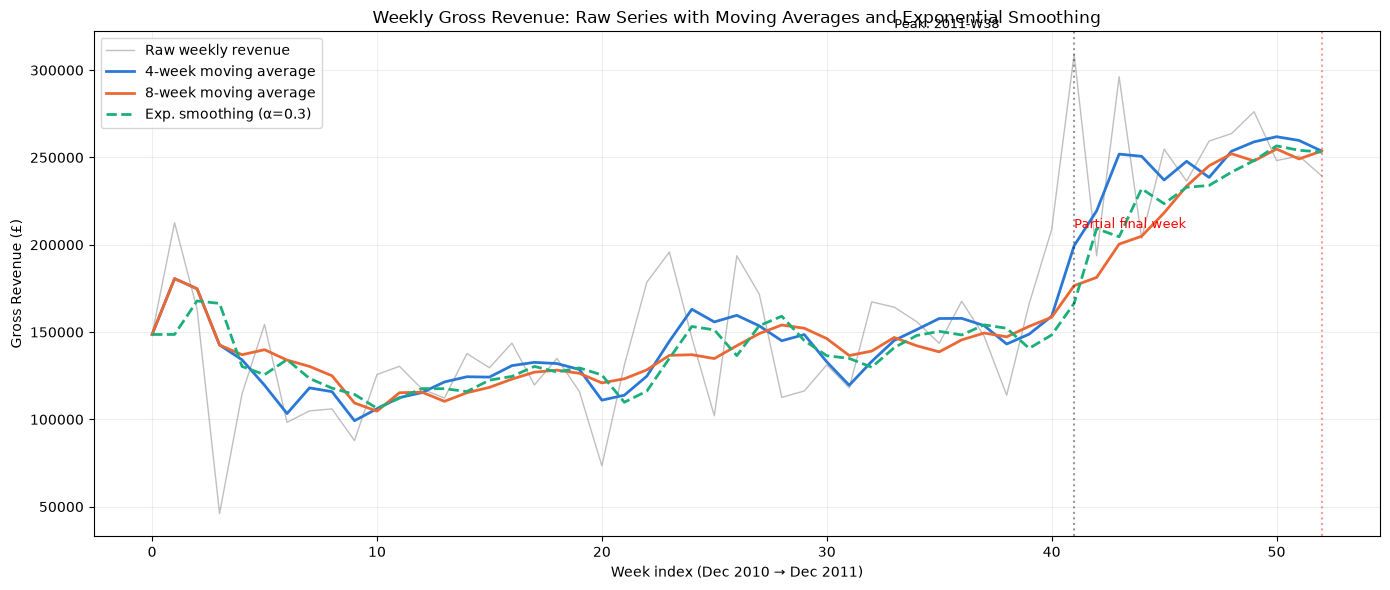

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(weekly_clean.index, weekly_clean['GrossRevenue'], color='gray', alpha=0.5, linewidth=1, label='Raw weekly revenue')
ax.plot(weekly_clean.index, weekly_clean['MA_4wk'], color='#2a78d6', linewidth=2, label='4-week moving average')
ax.plot(weekly_clean.index, weekly_clean['MA_8wk'], color='#eb6834', linewidth=2, label='8-week moving average')
ax.plot(weekly_clean.index, weekly_clean['SES'], color='#1baf7a', linewidth=2, linestyle='--', label='Exp. smoothing (α=0.3)')

# Mark the peak week and the known-partial final week
peak_idx = weekly_clean['GrossRevenue'].idxmax()
ax.axvline(peak_idx, color='black', linestyle=':', alpha=0.4)
ax.annotate('Peak: 2011-W38', xy=(peak_idx, weekly_clean['GrossRevenue'].max()), 
            xytext=(peak_idx-8, weekly_clean['GrossRevenue'].max()+15000), fontsize=9)

ax.axvline(len(weekly_clean)-1, color='red', linestyle=':', alpha=0.4)
ax.annotate('Partial final week', xy=(len(weekly_clean)-1, weekly_clean['GrossRevenue'].iloc[-1]),
            xytext=(len(weekly_clean)-12, weekly_clean['GrossRevenue'].iloc[-1]-30000), fontsize=9, color='red')

ax.set_xlabel('Week index (Dec 2010 → Dec 2011)')
ax.set_ylabel('Gross Revenue (£)')
ax.set_title('Weekly Gross Revenue: Raw Series with Moving Averages and Exponential Smoothing')
ax.legend(loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../results/figures/weekly_revenue_trend.png', dpi=150, bbox_inches='tight')

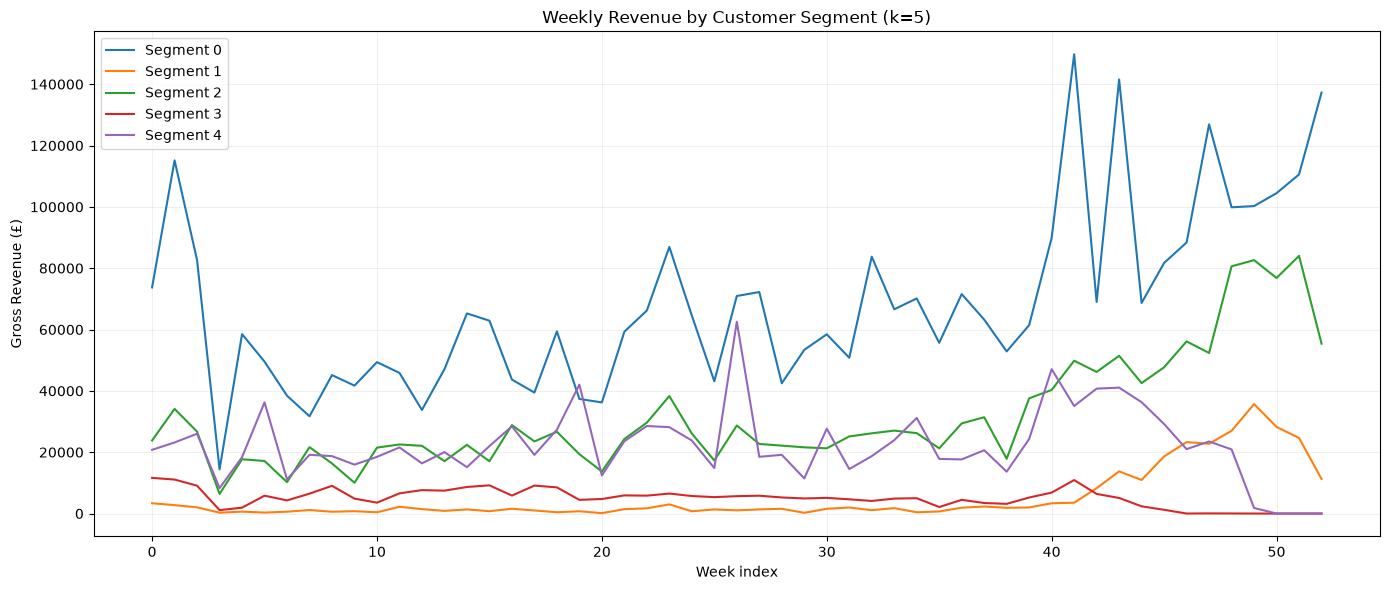

In [15]:
# Segment comparison plot
fig, ax = plt.subplots(figsize=(14, 6))
for seg in pivot_segment.columns:
    ax.plot(range(len(pivot_segment)), pivot_segment[seg], label=f'Segment {int(seg)}', linewidth=1.5)

ax.set_xlabel('Week index')
ax.set_ylabel('Gross Revenue (£)')
ax.set_title('Weekly Revenue by Customer Segment (k=5)')
ax.legend(loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../results/figures/weekly_revenue_by_segment.png', dpi=150, bbox_inches='tight')

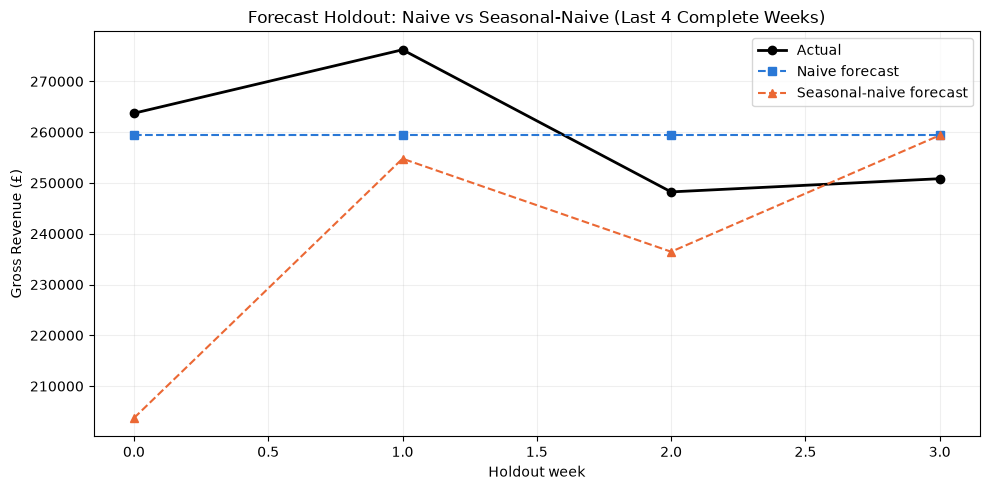

In [16]:
# Forecast holdout comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
test_weeks = range(len(test))
ax.plot(test_weeks, test['GrossRevenue'].values, marker='o', color='black', label='Actual', linewidth=2)
ax.plot(test_weeks, naive_forecast, marker='s', color='#2a78d6', label='Naive forecast', linestyle='--')
ax.plot(test_weeks, seasonal_naive_forecast, marker='^', color='#eb6834', label='Seasonal-naive forecast', linestyle='--')

ax.set_xlabel('Holdout week')
ax.set_ylabel('Gross Revenue (£)')
ax.set_title('Forecast Holdout: Naive vs Seasonal-Naive (Last 4 Complete Weeks)')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../results/figures/forecast_holdout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()